<a href="https://colab.research.google.com/github/fernandasouzx/Trabalho-final-IA/blob/dev/C%C3%B3pia_de_Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Instalação e Importação
!pip install optuna lightgbm scikit-learn -q
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
from scipy.stats import uniform, randint, loguniform
from sklearn.preprocessing import LabelEncoder

In [ ]:
#1.1 EDA
df = pd.read_csv("train.csv")
print(f"Shape: {df.shape}, Colunas: {df.columns.tolist()}")
print("Nulos por coluna:\n", df.isnull().sum())


Shape: (498320, 32), Colunas: ['DT_NOTIFIC', 'CS_SEXO', 'CO_RG_RESI', 'ID_MN_RESI', 'CS_ZONA', 'NU_IDADE_N', 'CS_ESCOL_N', 'CS_RACA', 'SG_UF', 'CS_GESTANT', 'PUERPERA', 'DIABETES', 'PNEUMOPATI', 'IMUNODEPRE', 'RENAL', 'OBESIDADE', 'OBES_IMC', 'CARDIOPATI', 'SIND_DOWN', 'HEPATICA', 'FATOR_RISC', 'FEBRE', 'TOSSE', 'GARGANTA', 'DESC_RESP', 'DIARREIA', 'VOMITO', 'FADIGA', 'SATURACAO', 'DISPNEIA', 'VACINA', 'EVOLUCAO']
Nulos por coluna:
 DT_NOTIFIC         0
CS_SEXO            0
CO_RG_RESI     73185
ID_MN_RESI        44
CS_ZONA        52838
NU_IDADE_N         0
CS_ESCOL_N    146901
CS_RACA        19384
SG_UF             44
CS_GESTANT         0
PUERPERA      298765
DIABETES      252391
PNEUMOPATI    292402
IMUNODEPRE    295546
RENAL         292734
OBESIDADE     290862
OBES_IMC      483795
CARDIOPATI    236183
SIND_DOWN     298085
HEPATICA      297733
FATOR_RISC    179966
FEBRE          60770
TOSSE          52380
GARGANTA      124438
DESC_RESP      83604
DIARREIA      129733
VOMITO        136

In [ ]:
df = df.drop(columns=['CARDIOPATI', 'CS_GESTANT', 'SIND_DOWN', 'PNEUMOPATI', 'CO_RG_RESI'])

In [ ]:
# 2. Preprocessamento
def preprocess_data(df, is_train=True, mortalidade_uf=None):
    df = df.copy()

    # # Drop early irrelevantes (PDF: opcional/altos nulos)
    # cols_to_drop_early = ['DT_NOTIFIC', 'OBES_IMC', 'VOMITO', 'TOSSE', 'PUERPERA']
    # for col in cols_to_drop_early:
    #     if col in df.columns:
    #         df.drop(col, axis=1, inplace=True, errors='ignore')
    #         print(f"Dropping {col} early.")

    # Handle SATURACAO before converting other columns to category
    if 'SATURACAO' in df.columns:
        # Passo 1: Crie a flag para valores faltantes ANTES de preencher
        df['SATURACAO_faltante'] = df['SATURACAO'].isnull().astype(int)

        # Passo 2: Agora, pode preencher com a mediana
        mediana_sat = df['SATURACAO'].median() if df['SATURACAO'].isnull().sum() < len(df) else 98 # 98 é um valor mais plausível que 0
        df['SATURACAO'] = pd.to_numeric(df['SATURACAO'], errors='coerce').fillna(mediana_sat)


    # Lista de colunas que são essencialmente categóricas (excluding SATURACAO)
    cols_to_process_as_category = [
      'DIABETES', 'IMUNODEPRE','RENAL','OBESIDADE','FADIGA','VACINA_COV',
      'HEPATICA', 'FATOR_RISC', 'FEBRE', 'TOSSE','GARGANTA','DISPNEIA',
      'DESC_RESP','SATURACAO','DIARREIA','VOMITO', 'CS_RACA', 'CS_ZONA'
    ]

    for col in cols_to_process_as_category:
        if col in df.columns:
            # 1. Preenche o valor nulo com um número (pode ser 9, -1, etc.)
            # Usamos string para garantir que não será tratado como número
            fill_value = '9'
            df[col] = df[col].fillna(fill_value)

            # # 2. Garante que todos os valores sejam strings antes de converter
            df[col] = df[col].astype(str)

            # 3. [A MUDANÇA MAIS IMPORTANTE] Converte a coluna para o tipo 'category'
            df[col] = df[col].astype('category')

    # Específicos
    if 'CS_SEXO' in df.columns:
      df['CS_SEXO'] = df['CS_SEXO'].astype('category')
    #     df['CS_SEXO'] = df['CS_SEXO'].map({'F': 0, 'M': 1}).fillna(9).astype(int)


    if 'CS_ESCOL_N' in df.columns:
      # Passo 1: Crie uma "flag" que sinaliza onde os dados estavam faltando.
      df['CS_ESCOL_N_faltante'] = df['CS_ESCOL_N'].isnull().astype(int)

      # Passo 2: Agora, preencha os valores nulos com a mediana.
      mediana_escol = df['CS_ESCOL_N'].median() if df['CS_ESCOL_N'].isnull().sum() < len(df) else 0
      df['CS_ESCOL_N'] = df['CS_ESCOL_N'].fillna(mediana_escol)

      # A criação da feature 'baixa_educacao' continua igual.
      df['baixa_educacao'] = (df['CS_ESCOL_N'] <= 3).astype(int)


    for col in ['SG_UF']:
        if col in df.columns:
          df[col] = df[col].fillna('IGNORADO')
            # df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'IGNORADO')

    # Engenharia de features
    comorbidades = [c for c in ['DIABETES', 'OBESIDADE', 'RENAL',
                            'HEPATICA', 'IMUNODEPRE'] if c in df.columns]
    sintomas = [s for s in ['FEBRE', 'GARGANTA', 'DISPNEIA', 'FADIGA', 'SATURACAO', 'DESC_RESP', 'DIARREIA','VOMITO']
            if s in df.columns]

    # Garanta que todas as colunas sejam numéricas antes de somar.
    # O 'errors='coerce'' transforma qualquer valor não numérico em Nulo (NaN).
    for col in comorbidades + sintomas:
        if col in df.columns:
            # 1. Substitui o valor 2 (Não) por 0.
            df[col] = df[col].replace(2, 0)
            # 2. Converte para numérico. NÃO usamos .fillna(0) aqui.
            # Os NaNs originais (Ignorado) são preservados.
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Agora a soma funcionará com segurança, pois todas as colunas são numéricas.
    df['total_comorbidades'] = df[comorbidades].sum(axis=1) if comorbidades else 0
    df['total_sintomas'] = df[sintomas].sum(axis=1) if sintomas else 0


    if 'NU_IDADE_N' in df.columns:
        bins = [0, 18, 30, 60, 80, 120]
        labels = ['0-18', '19-30', '31-60', '61-80', '80+']
        df['FAIXA_ETARIA'] = pd.cut(df['NU_IDADE_N'], bins=bins, labels=labels, right=False).astype(str)
        df['idoso_com_comorbidade'] = ((df['NU_IDADE_N'] >= 60) & (df['total_comorbidades'] > 0)).astype(int)
        df['interacao_idade_risco'] = np.minimum(df['NU_IDADE_N'] * df['total_comorbidades'], 100)

    mapa_regioes = {"AC": "Norte", "AM": "Norte", "AP": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
                    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
                    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
                    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
                    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
                    "PR": "Sul", "RS": "Sul", "SC": "Sul"}


    if 'SG_UF' in df.columns:
        df['REGIAO'] = df['SG_UF'].map(mapa_regioes).fillna('IGNORADO').astype(str)

        if is_train and 'EVOLUCAO' in df.columns:
            # Calcula a média global de mortalidade
            global_mean = df['EVOLUCAO'].mean()

            # Agrupa por UF para obter a média e a contagem de cada estado
            agg = df.groupby('SG_UF')['EVOLUCAO'].agg(['mean', 'count'])

            # Define o "peso" da suavização. Quanto maior, mais forte a influência da média global.
            k = 25

            # Aplica a fórmula de suavização
            agg['smoothed'] = (agg['mean'] * agg['count'] + global_mean * k) / (agg['count'] + k)

            # Cria o dicionário com os valores suavizados
            mortalidade_uf = agg['smoothed'].to_dict()
            mortalidade_uf['global_mean'] = global_mean # Salva a média global para o teste

        if mortalidade_uf:
            # Para o teste, usa a média global para qualquer estado não visto no treino
            mean_to_fill = mortalidade_uf.get('global_mean', 0.5)
            df['risco_uf'] = df['SG_UF'].map(mortalidade_uf).fillna(mean_to_fill)

    # Proxy temporal (sem DT_SIN_PRI, use DT_NOTIFIC antes do drop)
    if 'DT_NOTIFIC' in df.columns:
        df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
        df['SEM_PRI_proxy'] = df['DT_NOTIFIC'].dt.isocalendar().week - 1
        df['mes_notific'] = df['DT_NOTIFIC'].dt.month.fillna(6).astype(int)
        df['delay_sint_notif'] = 3 + df['mes_notific'] * 0.5  # Proxy
        df.drop('DT_NOTIFIC', axis=1, inplace=True)

    # One-Hot e numérico
    categorical_cols = [c for c in ['FAIXA_ETARIA', 'REGIAO'] if c in df.columns]
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
    for col in df.columns:
        if df[col].dtype == 'object':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    if not is_train and 'EVOLUCAO' in df.columns:
        df = df.drop(columns=['EVOLUCAO'])

    print(f"Shape final: {df.shape}, Nulos totais: {df.isnull().sum().sum()}")
    return df, mortalidade_uf if is_train else None

In [ ]:
# 3. Pipeline
# Preprocess
df_train = pd.read_csv("train.csv")
df_train_processed, mortalidade_uf = preprocess_data(df_train, is_train=True)
df_train_processed = df_train_processed.dropna(subset=['EVOLUCAO'])
X = df_train_processed.drop(columns=['EVOLUCAO'])
y = df_train_processed['EVOLUCAO'].astype(int)

Shape final: (498320, 51), Nulos totais: 0


## Divide os dados de forma estratégica e corrigir o desbalanceamento de classes no conjunto de treino.

In [ ]:
# Splits + SMOTE
X_temp, X_holdout, y_temp, y_holdout = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)
smote = SMOTE(random_state=60)
# Cast X_train to float to avoid TypeError with SMOTE
X_train_bal, y_train_bal = smote.fit_resample(X_train.astype('float64'), y_train)
print("Balanceado:", pd.Series(y_train_bal).value_counts(normalize=True))

Balanceado: EVOLUCAO
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# --- Parâmetros Iniciais para o XGBoost ---
# Estes são parâmetros iniciais razoáveis. O ideal é otimizá-los depois.

# Ponto importante: tratamento de classes desbalanceadas no XGBoost
# Calcule o 'scale_pos_weight' para ajudar o modelo com o desbalanceamento
# A fórmula é: (número de amostras da classe negativa) / (número de amostras da classe positiva)
ratio = len(y[y == 0]) / len(y[y == 1])
print(f"Ratio para scale_pos_weight: {ratio:.2f}")

params_iniciais_xgb = {
    'objective': 'binary:logistic', # Objetivo para classificação binária
    'eval_metric': 'logloss',       # Métrica para avaliação interna
    'n_estimators': 1000,           # Número de árvores. Usaremos early stopping, então pode ser alto.
    'learning_rate': 0.05,          # Taxa de aprendizado
    'max_depth': 4,                 # Profundidade máxima da árvore (bom valor para começar)
    'subsample': 0.8,               # Fração de amostras de treino por árvore
    'colsample_bytree': 0.8,        # Fração de features por árvore
    'gamma': 0.1,                   # Parâmetro de regularização
    'scale_pos_weight': ratio,      # !! Essencial para classes desbalanceadas !!
    'random_state': 42,
    'n_jobs': -1,                   # Usar todos os cores do processador
    'use_label_encoder': False      # Recomendação da biblioteca para evitar warnings
}

# Crie o modelo XGBoost com os parâmetros definidos
modelo_xgb = xgb.XGBClassifier(**params_iniciais_xgb)

# --- Avaliação com Validação Cruzada (A forma confiável) ---
# Use os dados de treino COMPLETOS (X, y)
X_treino_completo = X
y_treino_completo = y

# Crie os folds para a validação cruzada
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calcule os scores de F1 para cada fold
print("\nIniciando a avaliação do XGBoost com Validação Cruzada...")
f1_scores_xgb = cross_val_score(modelo_xgb, X_treino_completo, y_treino_completo, cv=cv_folds, scoring='f1')

# Veja o resultado
print(f"\nScores F1 do XGBoost em cada fold: {f1_scores_xgb}")
print(f"Média do F1-Score (CV) para XGBoost: {np.mean(f1_scores_xgb):.4f}")
print(f"Desvio Padrão do F1-Score (CV) para XGBoost: {np.std(f1_scores_xgb):.4f}")

Ratio para scale_pos_weight: 1.90

Iniciando a avaliação do XGBoost com Validação Cruzada...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:45:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:46:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:47:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:47:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:48:38] WARNING: /w


Scores F1 do XGBoost em cada fold: [0.65443256 0.65910174 0.6559156  0.65793389 0.65300014]
Média do F1-Score (CV) para XGBoost: 0.6561
Desvio Padrão do F1-Score (CV) para XGBoost: 0.0022


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:49:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


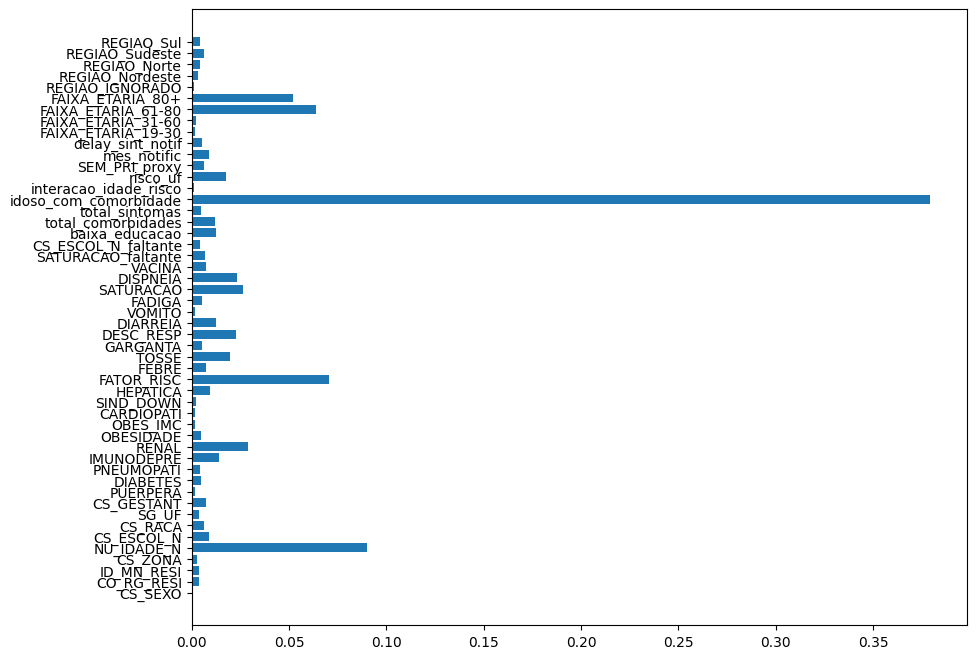

In [ ]:
# Treinar com X e y completos
modelo_xgb.fit(X, y)

# Depois disso você pode acessar a importância das features
import matplotlib.pyplot as plt
importances = modelo_xgb.feature_importances_
plt.figure(figsize=(10,8))
plt.barh(X.columns, importances)
plt.show()

Top 20 variáveis mais correlacionadas com EVOLUCAO (Pearson):
NU_IDADE_N               0.367477
idoso_com_comorbidade    0.332424
FAIXA_ETARIA_80+         0.248094
risco_uf                 0.167117
FAIXA_ETARIA_61-80       0.159275
TOSSE                    0.096717
CARDIOPATI               0.085907
FEBRE                    0.085508
SIND_DOWN                0.078410
GARGANTA                 0.078210
REGIAO_Nordeste          0.076923
PNEUMOPATI               0.075815
PUERPERA                 0.075410
DIARREIA                 0.072144
VOMITO                   0.061054
total_sintomas           0.059915
FADIGA                   0.056310
baixa_educacao           0.051649
VACINA                   0.043558
interacao_idade_risco    0.038403
Name: EVOLUCAO, dtype: float64

Top 20 variáveis mais correlacionadas com EVOLUCAO (Spearman):
NU_IDADE_N               0.379917
idoso_com_comorbidade    0.332424
FAIXA_ETARIA_80+         0.248094
FAIXA_ETARIA_61-80       0.159275
risco_uf                 0.

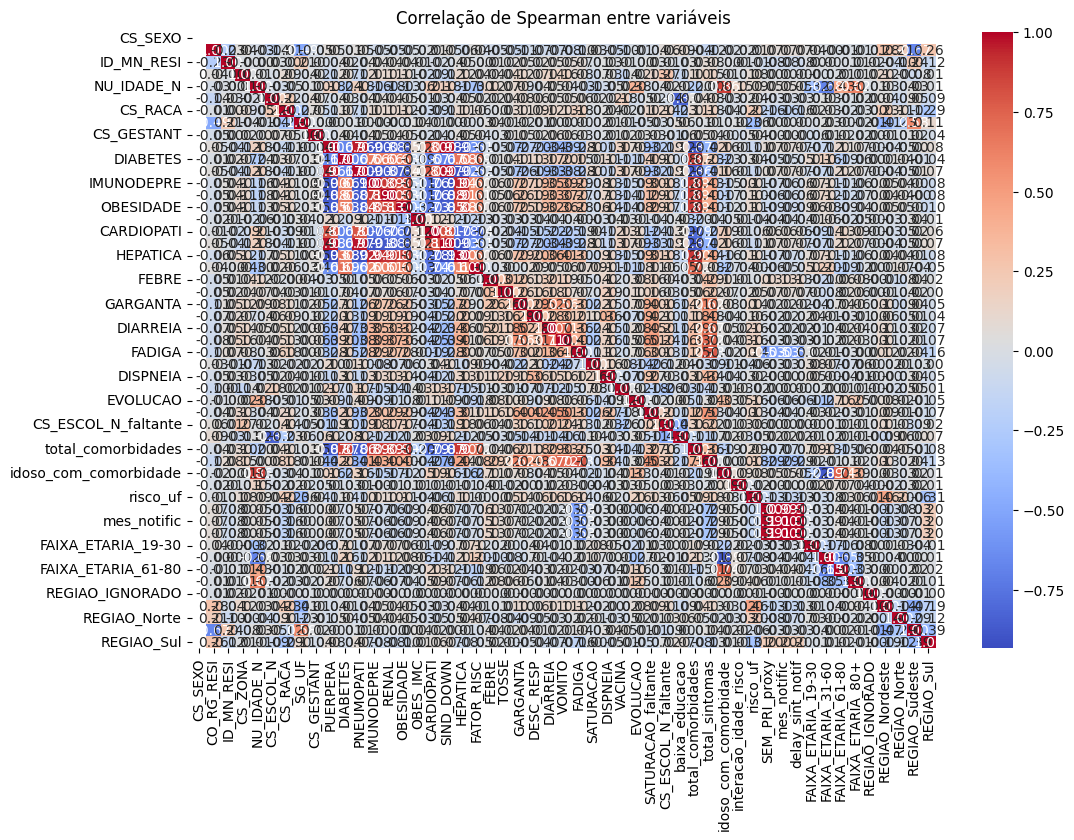

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleciona apenas colunas numéricas
df_num = df_train_processed.select_dtypes(include='number')

# --- Correlação de Pearson ---
cor_pearson = df_num.corr(method='pearson')['EVOLUCAO'].sort_values(ascending=False)
print("Top 20 variáveis mais correlacionadas com EVOLUCAO (Pearson):")
print(cor_pearson[1:21])  # Ignora EVOLUCAO em si

# --- Correlação de Spearman ---
cor_spearman = df_num.corr(method='spearman')['EVOLUCAO'].sort_values(ascending=False)
print("\nTop 20 variáveis mais correlacionadas com EVOLUCAO (Spearman):")
print(cor_spearman[1:21])  # Ignora EVOLUCAO em si

# --- Heatmap visualizando correlação geral (Spearman) ---
plt.figure(figsize=(12,8))
sns.heatmap(df_num.corr(method='spearman'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlação de Spearman entre variáveis")
plt.show()


In [ ]:
 #4. Treinamento Direto do Modelo (Baseline)
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report

# Definimos os modelos base com parâmetros padrão
base_models = [
    # ('lgbm', lgb.LGBMClassifier(random_state=42, verbose=-1)),
    ('xgb', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
]

# Definimos o meta-modelo
meta_model = LogisticRegression(random_state=42)

# Criamos o modelo Stacking
# Usamos todo o X_train_bal para treinar
baseline_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

print("Iniciando o treinamento do modelo de baseline (Stacking)...")
# Treinamos diretamente nos dados de treino (balanceados)
baseline_model.fit(X_train_bal, y_train_bal)
print("Treinamento concluído!")


Iniciando o treinamento do modelo de baseline (Stacking)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:50:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:51:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:51:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:51:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:51:40] WARNING: /w

Treinamento concluído!


In [ ]:
# 5. Avaliação no Holdout
print("\nAvaliando o modelo no conjunto de Holdout...")
# Fazemos a previsão de probabilidade nos dados de holdout (que não foram usados no treino)
y_pred_proba_holdout = baseline_model.predict_proba(X_holdout)[:, 1]

# Usamos um threshold padrão de 0.5 para começar
y_pred_final = (y_pred_proba_holdout > 0.5).astype(int)

print(f"Resultado com threshold padrão (0.5):")
print(f"F1-Score no Holdout: {f1_score(y_holdout, y_pred_final):.4f}")
print(classification_report(y_holdout, y_pred_final))


Avaliando o modelo no conjunto de Holdout...
Resultado com threshold padrão (0.5):
F1-Score no Holdout: 0.6208
              precision    recall  f1-score   support

           0       0.79      0.83      0.81     16314
           1       0.65      0.59      0.62      8602

    accuracy                           0.75     24916
   macro avg       0.72      0.71      0.72     24916
weighted avg       0.75      0.75      0.75     24916



In [ ]:
# 6. Submissão (se necessário)
print("\nPreparando o arquivo de submissão...")
df_test = pd.read_csv("test.csv")
df_test_processed, _ = preprocess_data(df_test, is_train=False, mortalidade_uf=mortalidade_uf)

# Garantir que as colunas do df_test sejam as mesmas do df de treino
df_test_processed = df_test_processed.reindex(columns=X.columns, fill_value=0)

# Previsão nos dados de teste
predictions = baseline_model.predict_proba(df_test_processed)[:, 1]

submission_ids = df_test['ID'] if 'ID' in df_test else df_test.index
submission_df = pd.DataFrame({'ID': submission_ids, 'EVOLUCAO': (predictions > 0.5).astype(int)})
submission_df.to_csv('submission_bin.csv', index=False)
print("Arquivo 'submission_bin.csv' criado com sucesso!")


Preparando o arquivo de submissão...
Shape final: (124581, 51), Nulos totais: 0
Arquivo 'submission_bin.csv' criado com sucesso!
